In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [12]:
df = pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [13]:
del df['Weight']

In [14]:
df.head()

,Gender,Height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


In [16]:
df.Height.describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

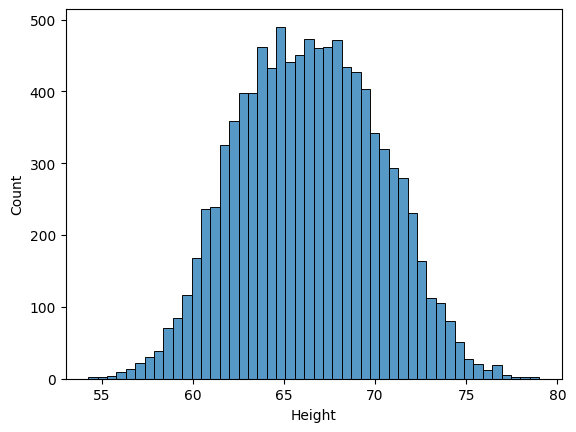

In [20]:
sns.histplot(df.Height)

<Axes: xlabel='Height', ylabel='Count'>

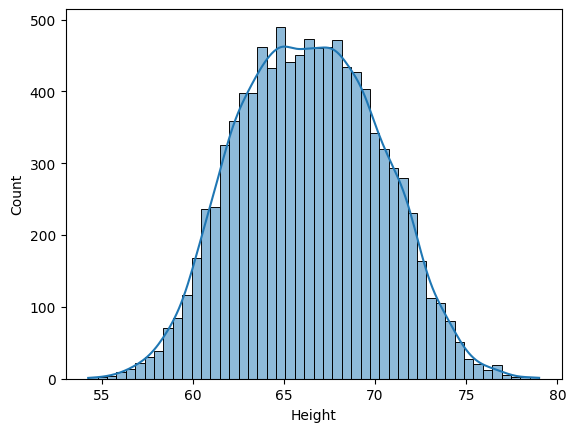

In [21]:
sns.histplot(df.Height, kde = True)

In [22]:
mean = df.Height.mean()
mean

np.float64(66.36755975482124)

In [24]:
std_deviation = df.Height.std()
std_deviation

np.float64(3.8475281207732293)

In [ ]:
mean - 3 * std_deviation

np.float64(54.82497539250156)

In [ ]:
mean + 3 * std_deviation


np.float64(77.91014411714093)

**Any thing outside of (54.82 - 77.91) are outlier** 

In [27]:
df[df.Height < 54.82]

,Gender,Height
6624,Female,54.616858
9285,Female,54.263133


In [28]:
df[df.Height > 77.91]

,Gender,Height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374


In [29]:
df[ (df.Height < 54.82) | (df.Height > 77.91)]

,Gender,Height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [ ]:
df_no_outlier = df[ (df.Height > 54.82) & (df.Height < 77.91)] # reomoving and storing data without outliers

In [35]:
df_no_outlier

,Gender,Height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796
...,...,...
9995,Female,66.172652
9996,Female,67.067155
9997,Female,63.867992
9998,Female,69.034243


In [37]:
df_no_outlier.shape

(9993, 2)

**Your data is cleaned now and you can train your model perfectly.**

In [40]:
df['z_score'] = (df.Height - df.Height.mean())/df.Height.std()
df['z_score']

0       1.943964
1       0.627505
2       2.012343
3       1.393991
4       0.913375
          ...   
9995   -0.050658
9996    0.181830
9997   -0.649655
9998    0.693090
9999   -1.149651
Name: z_score, Length: 10000, dtype: float64

In [41]:
df.head()

,Gender,Height,z_score
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [42]:
df[df.z_score>3]

,Gender,Height,z_score
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [44]:
df[(df.z_score < -3) | (df.z_score > 3)]

,Gender,Height,z_score
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


**Here as you can see the outliers, an alternative ways to find out outliers** 

In [46]:
df_no_outlier = df[(df.z_score > -3) & (df.z_score < 3)]
df_no_outlier

,Gender,Height,z_score
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375
...,...,...,...
9995,Female,66.172652,-0.050658
9996,Female,67.067155,0.181830
9997,Female,63.867992,-0.649655
9998,Female,69.034243,0.693090
